In [7]:
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, cross_val_predict
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Dataset ALEX (Ss_CODE)

## S/ SMOTE

In [4]:
# -------- 1) Carregar dados --------
# Ficheiro base (export do Revit) com separador ';'
RAW_PATH = 'DATASET_ALEX.csv'

df_raw = pd.read_csv(RAW_PATH, sep=';')
print('raw shape:', df_raw.shape)
df_raw.head(3)

raw shape: (80646, 19)


,[I] Family and Type,[I] Type,[I] Workset,[I] Category,[I] IfcGUID,[I] Level,[I] Mark,[T] Type IfcGUID,[T] Workset,[T] Family Name,[I] Construction Block,[T] Classification Number,[T] Type Name,[T] Category,[I] Type Id,[I] Volume,Target (EF_CODE),Target (Ss_CODE),Target (Pr_CODE)
0,TPF-ValveBox.Xylem-Standard-GEOM: Standard,Standard,DRG-Exterior,Generic Models,082Y9U8n57RxOQ13jCCxiV,Ground Floor,NaN,082Y9U8n57RxOQ13jCCxXM,Family : Generic Models : TPF-ValveBox.Xylem-...,TPF-ValveBox.Xylem-Standard-GEOM,NaN,NaN,Standard,Generic Models,1731873.0,0.04 m³,0,0,0
1,TPF-Wastewater-Contaminated-Station.Flygt-Auto...,Standard,DRG-Exterior,Generic Models,082Y9U8n57RxOQ13jCCxWl,Ground Floor,NaN,082Y9U8n57RxOQ13jCCx7K,Family : Generic Models : TPF-Wastewater-Cont...,TPF-Wastewater-Contaminated-Station.Flygt-Auto...,NaN,NaN,Standard,Generic Models,1729699.0,0.76 m³,0,0,0
2,TPF-InspectionBox-Blind-RefLevels: 0.60 x 0.60,0.60 x 0.60,DRG,Mechanical Equipment,1uIinGoWPC5RVu5GeQ3hP0,Ground Floor,CVO3C01.3,3BOmqxrYf5hxpVbPIqK0b6,Family : Mechanical Equipment : TPF-Inspectio...,TPF-InspectionBox-Blind-RefLevels,O3,NaN,0.60 x 0.60,Mechanical Equipment,1744703.0,0.85 m³,0,0,0


In [8]:
# -------- 2) Definir colunas (features + target) --------
# Colunas a usar (conforme indicado)
FEATURE_COLS = [
    '[I] Family and Type',
    '[I] Type',
    '[I] Workset',
    '[I] Category',
    '[I] IfcGUID',
    '[I] Level',
    '[I] Mark',
    '[T] Type IfcGUID',
    '[T] Workset',
    '[T] Family Name',
    '[I] Construction Block',
    '[T] Classification Number',
    '[T] Type Name',
    '[T] Category',
    '[I] Type Id',
    '[I] Volume',
]

# Escolhe 1 target de cada vez
TARGET_COL = 'Target (Ss_CODE)'

# Para o SMOTE (k_neighbors=5 por defeito) não falhar
MIN_SAMPLES_PER_CLASS = 6

In [9]:
# -------- 3) Preparar X e y (limpeza + encoding) --------
missing = [c for c in (FEATURE_COLS + [TARGET_COL]) if c not in df_raw.columns]
if missing:
    raise ValueError(f'Faltam colunas no CSV: {missing}')

df = df_raw[FEATURE_COLS + [TARGET_COL]].copy()

def parse_volume_m3(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    s = s.replace('m³', '').replace('m3', '')
    s = s.replace(' ', '').replace(',', '.')
    s = re.sub(r'[^0-9eE+\-\.]', '', s)
    return pd.to_numeric(s, errors='coerce')

# normalizar tipos numéricos
if '[I] Type Id' in df.columns:
    df['[I] Type Id'] = pd.to_numeric(df['[I] Type Id'], errors='coerce')
if '[I] Volume' in df.columns:
    df['[I] Volume'] = df['[I] Volume'].apply(parse_volume_m3)

# target: remover '0' / vazio
y_raw = df[TARGET_COL].astype('string').str.strip()
mask_valid = y_raw.notna() & (y_raw != '') & (y_raw != '0')
df = df.loc[mask_valid].copy()
y_raw = y_raw.loc[mask_valid]

# filtrar classes raras (SMOTE-safe)
vc = y_raw.value_counts()
keep_classes = vc[vc >= MIN_SAMPLES_PER_CLASS].index
mask_keep = y_raw.isin(keep_classes)
df = df.loc[mask_keep].copy()
y_raw = y_raw.loc[mask_keep]

print('after filtering shape:', df.shape)
print('n_classes:', int(y_raw.nunique()))
print('min class count:', int(y_raw.value_counts().min()))

# X: one-hot encoding de todas as colunas categóricas
X_raw = df[FEATURE_COLS].copy()
X = pd.get_dummies(X_raw, dummy_na=True)
X = X.apply(pd.to_numeric, errors='coerce').fillna(0)

# y: label encoding
le = LabelEncoder()
y = le.fit_transform(y_raw.astype(str))

print('X shape:', X.shape, 'y shape:', y.shape)
print('classes:', len(le.classes_))

after filtering shape: (27872, 17)
n_classes: 34
min class count: 6
X shape: (27872, 27376) y shape: (27872,)
classes: 34


In [10]:
# -------- 4) Train/Test Split --------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

In [ ]:
# ---------- 1) Modelos: SEM e COM SMOTE ----------
# 1a) SEM SMOTE
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
pred_no = dt.predict(X_test)

# 1b) COM SMOTE (aplicado só no treino)
min_class_train = int(np.bincount(y_train).min())
if min_class_train < 2:
    raise ValueError('SMOTE não é possível: há classes com <2 amostras no treino.')

# SMOTE usa n_neighbors = k_neighbors + 1
k_neighbors = min(5, min_class_train - 1)
sm = SMOTE(random_state=42, k_neighbors=k_neighbors)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

dt_sm = DecisionTreeClassifier(random_state=42)
dt_sm.fit(X_train_sm, y_train_sm)
pred_sm = dt_sm.predict(X_test)

print('SMOTE k_neighbors:', k_neighbors)

In [ ]:
# ---------- 2) Métricas no TESTE ----------
def print_test_metrics(y_true, y_pred, tag):
    acc = accuracy_score(y_true, y_pred)
    bal = balanced_accuracy_score(y_true, y_pred)
    f1m = f1_score(y_true, y_pred, average="macro")
    f1w = f1_score(y_true, y_pred, average="weighted")
    print(f"\n=== TESTE — {tag} ===")
    print(f"Accuracy:         {acc:.4f}")
    print(f"Balanced Accuracy:{bal:.4f}")
    print(f"F1-macro:         {f1m:.4f}")
    print(f"F1-weighted:      {f1w:.4f}")
    print("\nClassification report:")
    print(classification_report(y_true, y_pred, digits=4))
    return acc, bal, f1m, f1w

acc_no, bal_no, f1m_no, f1w_no = print_test_metrics(y_test, pred_no, "Decision Tree (SEM SMOTE)")
acc_sm, bal_sm, f1m_sm, f1w_sm = print_test_metrics(y_test, pred_sm, "Decision Tree (COM SMOTE)")



=== TESTE — Decision Tree (SEM SMOTE) ===
Accuracy:         0.9919
Balanced Accuracy:0.9598
F1-macro:         0.9551
F1-weighted:      0.9917

Classification report:
              precision    recall  f1-score   support

           0     1.0000    0.9961    0.9981       771
           1     0.9922    0.9954    0.9938      1525
           2     0.9901    1.0000    0.9950       100
           3     0.9545    1.0000    0.9767        21
           4     0.8684    0.7674    0.8148        43
           5     0.9091    1.0000    0.9524        10

    accuracy                         0.9919      2470
   macro avg     0.9524    0.9598    0.9551      2470
weighted avg     0.9917    0.9919    0.9917      2470


=== TESTE — Decision Tree (COM SMOTE) ===
Accuracy:         0.9891
Balanced Accuracy:0.9368
F1-macro:         0.9375
F1-weighted:      0.9892

Classification report:
              precision    recall  f1-score   support

           0     0.9948    0.9948    0.9948       771
           1  

<Figure size 640x480 with 0 Axes>

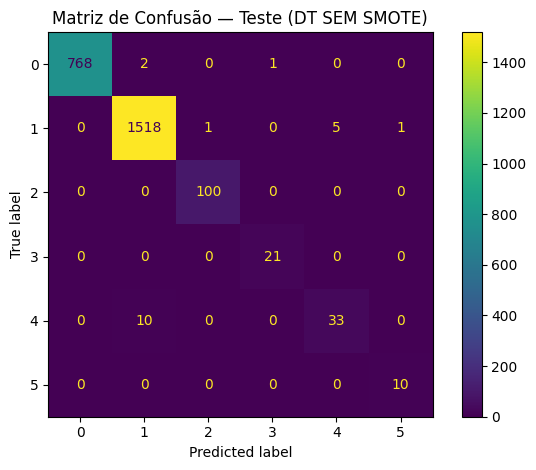

<Figure size 640x480 with 0 Axes>

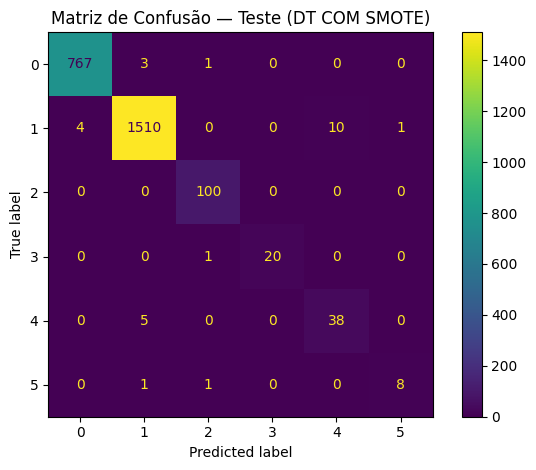

In [ ]:
# ---------- 3) Matrizes de confusão (TESTE) ----------
plt.figure()
cm_no = confusion_matrix(y_test, pred_no, labels=np.sort(np.unique(y)))
ConfusionMatrixDisplay(confusion_matrix=cm_no, display_labels=np.sort(np.unique(y))).plot(values_format="d")
plt.title("Matriz de Confusão — Teste (DT SEM SMOTE)")
plt.tight_layout()
plt.show()

plt.figure()
cm_sm = confusion_matrix(y_test, pred_sm, labels=np.sort(np.unique(y)))
ConfusionMatrixDisplay(confusion_matrix=cm_sm, display_labels=np.sort(np.unique(y))).plot(values_format="d")
plt.title("Matriz de Confusão — Teste (DT COM SMOTE)")
plt.tight_layout()
plt.show()


Top 10 features — DT SEM SMOTE:
               Feature  Importance
3               Height    0.687152
18     Category_Floors    0.081782
24      Category_Walls    0.059876
13          Centroid_Z    0.031103
5          Base_offset    0.030606
20     Category_Stairs    0.024155
1                 Area    0.016448
0               Volume    0.011373
4      Thickness/Width    0.011310
10  Bounding_Box_Depth    0.007907

Top 10 features — DT COM SMOTE:
                Feature  Importance
3                Height    0.193114
4       Thickness/Width    0.170917
10   Bounding_Box_Depth    0.170001
13           Centroid_Z    0.156339
20      Category_Stairs    0.135255
9   Bounding_Box_Height    0.104709
11           Centroid_X    0.030901
24       Category_Walls    0.010314
5           Base_offset    0.004947
1                  Area    0.004593


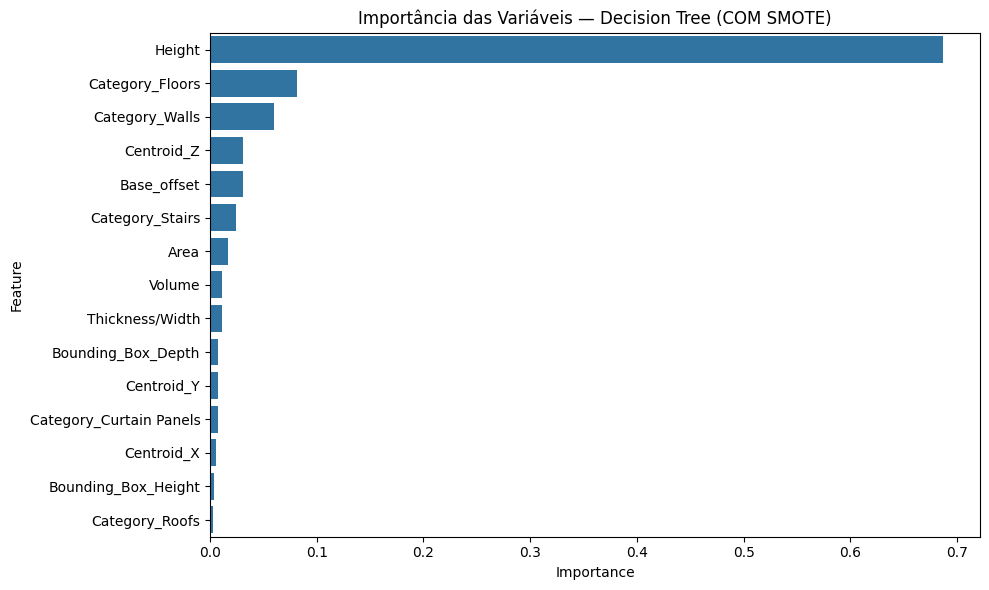

In [ ]:
# ---------- 4) Importância das variáveis ----------
# Se tiveres a lista de features (ex.: features4_1), usa-a; senão usa X.columns
feature_names = getattr(X, "columns", [f"feat_{i}" for i in range(X.shape[1])])

imp_no = pd.DataFrame({"Feature": feature_names, "Importance": dt.feature_importances_}) \
            .sort_values("Importance", ascending=False)
imp_sm = pd.DataFrame({"Feature": feature_names, "Importance": dt_sm.feature_importances_}) \
            .sort_values("Importance", ascending=False)

print("\nTop 10 features — DT SEM SMOTE:")
print(imp_no.head(10))
print("\nTop 10 features — DT COM SMOTE:")
print(imp_sm.head(10))

# Gráfico Top-15 (SEM SMOTE)
plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=imp_no.head(15))
plt.title("Importância das Variáveis — Decision Tree (COM SMOTE)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

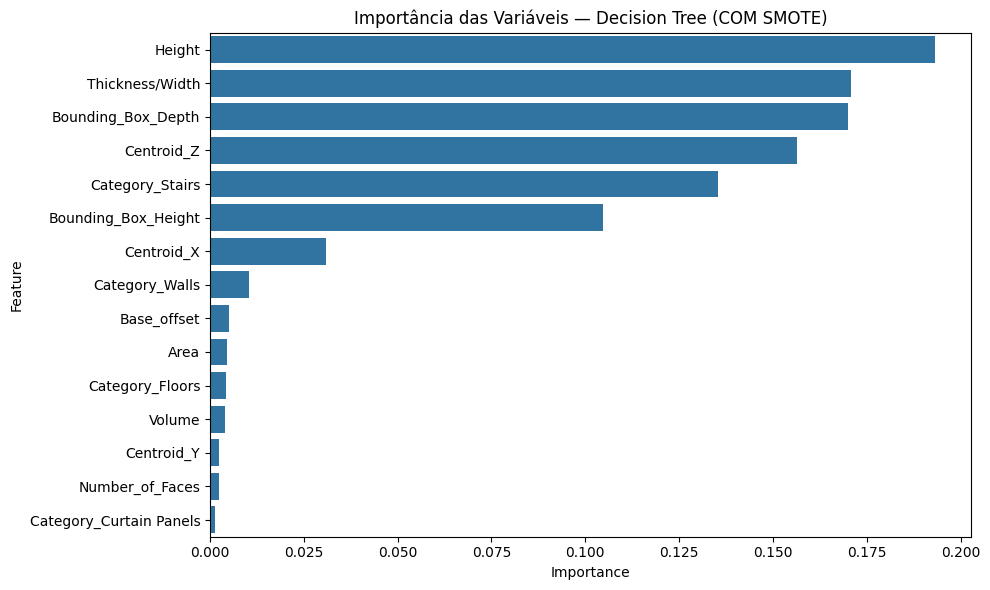

In [ ]:
# Gráfico Top-15 (COM SMOTE)
plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=imp_sm.head(15))
plt.title("Importância das Variáveis — Decision Tree (COM SMOTE)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [ ]:
# ---------- 5) Validação Cruzada (k-fold) com múltiplas métricas ----------
min_class = int(np.bincount(y).min())
n_splits = min(5, min_class)

if n_splits < 2:
    raise ValueError('CV não é possível: há classes com <2 amostras.')

cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
scorings = {
    'acc': 'accuracy',
    'bal_acc': 'balanced_accuracy',
    'f1_macro': 'f1_macro',
    'f1_weighted': 'f1_weighted',
}

# 5a) SEM SMOTE
dt_cv = DecisionTreeClassifier(random_state=42)
cv_no = cross_validate(dt_cv, X, y, cv=cv, scoring=scorings, n_jobs=-1, return_train_score=False)

# 5b) COM SMOTE (pipeline para evitar leakage) — só se houver amostras suficientes por classe no treino de cada fold
min_train_fold = min_class - int(np.ceil(min_class / n_splits))
pipe_smote_dt = None
cv_smote = None
if min_train_fold >= 2:
    k_neighbors = min(5, min_train_fold - 1)
    pipe_smote_dt = ImbPipeline(steps=[
        ('smote', SMOTE(random_state=42, k_neighbors=k_neighbors)),
        ('dt', DecisionTreeClassifier(random_state=42)),
    ])
    cv_smote = cross_validate(pipe_smote_dt, X, y, cv=cv, scoring=scorings, n_jobs=-1, return_train_score=False)
else:
    print('SMOTE em CV ignorado: classes demasiado pequenas por fold.')


def resumo_cv(nome, res):
    print(f"\n=== CV ({n_splits}-fold) — {nome} ===")
    for k in scorings.keys():
        vals = res[f'test_{k}']
        print(f"{k:12s}: {vals.mean():.4f} ± {vals.std():.4f}  (min={vals.min():.4f}, max={vals.max():.4f})")

resumo_cv('Decision Tree SEM SMOTE', cv_no)
if cv_smote is not None:
    resumo_cv('Decision Tree COM SMOTE', cv_smote)

print('CV n_splits:', n_splits)


=== CV (5-fold) — Decision Tree SEM SMOTE ===
acc         : 0.9896 ± 0.0015  (min=0.9870, max=0.9915)
bal_acc     : 0.9427 ± 0.0160  (min=0.9196, max=0.9634)
f1_macro    : 0.9403 ± 0.0148  (min=0.9182, max=0.9626)
f1_weighted : 0.9895 ± 0.0013  (min=0.9874, max=0.9914)

=== CV (5-fold) — Decision Tree COM SMOTE ===
acc         : 0.9887 ± 0.0007  (min=0.9874, max=0.9895)
bal_acc     : 0.9550 ± 0.0034  (min=0.9497, max=0.9592)
f1_macro    : 0.9464 ± 0.0058  (min=0.9352, max=0.9514)
f1_weighted : 0.9888 ± 0.0006  (min=0.9878, max=0.9894)



=== Matriz de Confusão — CV (SEM SMOTE) ===
      0     1    2    3    4   5
0  3845     9    1    1    0   0
1    10  7570    0    0   41   5
2     4     1  491    2    0   1
3     0     0    1  104    0   0
4     1    48    0    0  166   0
5     0     2    1    1    0  45

=== Matriz de Confusão — CV (COM SMOTE) ===
      0     1    2    3    4   5
0  3844     7    4    0    1   0
1    16  7549    2    0   54   5
2     2     3  493    1    0   0
3     0     0    1  104    0   0
4     0    42    0    0  173   0
5     1     0    0    0    1  47


<Figure size 640x480 with 0 Axes>

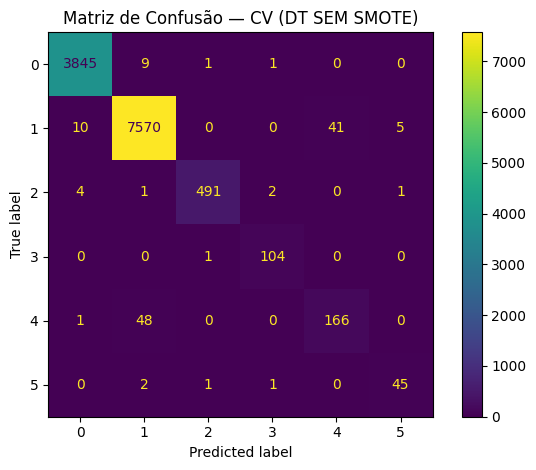

<Figure size 640x480 with 0 Axes>

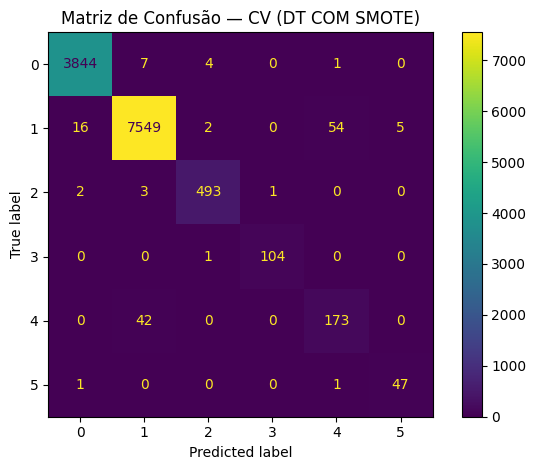

In [ ]:
# ---------- 6) Matrizes de confusão out-of-fold (CV) ----------
y_pred_cv_no = cross_val_predict(dt_cv, X, y, cv=cv, n_jobs=-1)

labels_sorted = np.sort(np.unique(y))

cm_cv_no = confusion_matrix(y, y_pred_cv_no, labels=labels_sorted)
print("\n=== Matriz de Confusão — CV (SEM SMOTE) ===")
print(pd.DataFrame(cm_cv_no, index=labels_sorted, columns=labels_sorted))

plt.figure()
ConfusionMatrixDisplay(confusion_matrix=cm_cv_no, display_labels=labels_sorted).plot(values_format='d')
plt.title('Matriz de Confusão — CV (DT SEM SMOTE)')
plt.tight_layout()
plt.show()

if pipe_smote_dt is not None:
    y_pred_cv_sm = cross_val_predict(pipe_smote_dt, X, y, cv=cv, n_jobs=-1)
    cm_cv_sm = confusion_matrix(y, y_pred_cv_sm, labels=labels_sorted)

    print("\n=== Matriz de Confusão — CV (COM SMOTE) ===")
    print(pd.DataFrame(cm_cv_sm, index=labels_sorted, columns=labels_sorted))

    plt.figure()
    ConfusionMatrixDisplay(confusion_matrix=cm_cv_sm, display_labels=labels_sorted).plot(values_format='d')
    plt.title('Matriz de Confusão — CV (DT COM SMOTE)')
    plt.tight_layout()
    plt.show()